### Learning Objectives
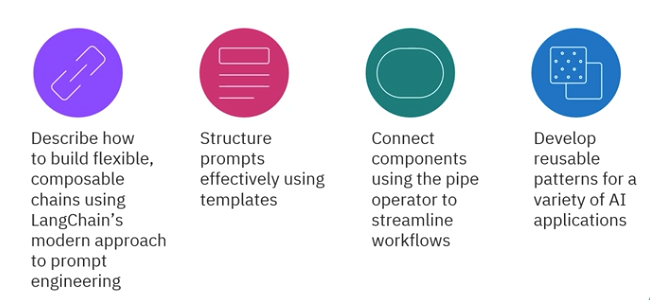

### LCEL
- LangChain Expression Language (LCEL)
- Build application using (|) operator
- Clean, redable flow of data from input to output
- Advantages
    - better composability
    - clear visualization of data flow
    - felxibility when constructing complex chains

### Create an LECL pattern
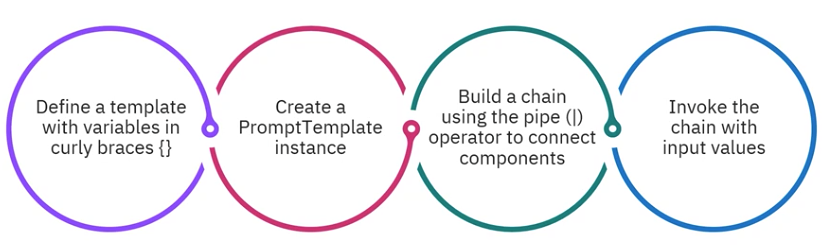


### Runnable vs LCEL
- Runnables
    - 2 type
    - interface and building blocks
    - connect the following components into a pipeline
        - LLMs
        - Retievers
        - Tools
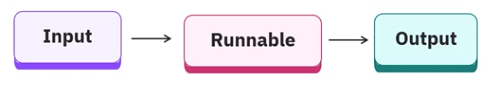

- RunnableSequence
    - chains componnets sequntially
    - pass output of one component to another

```python
from langchain_core.runnable import RUnnableSequence

chain = RunnableSequence([
    rummable1,
    runnable2
])
```

- RunnableParallel
    - runs multiple component concurrently

```python
from langchain_core.runnable import RunnableParallel

chain = RunnableParallel({
    "key1" runnable1,
    "key2": runnable2
})
```

- LCEL
    - insted of RunnableSequence
        - `chain = Runnable1 | Runnable2`
    - Handle type corecion automatically
        - convert regular code into runnable components
        - convert dictionaries to RunnableParallel and runctions to RunnableLambda


- LCEL: for simpler orchstration tasks
- LangGraph: suited for complex workflows

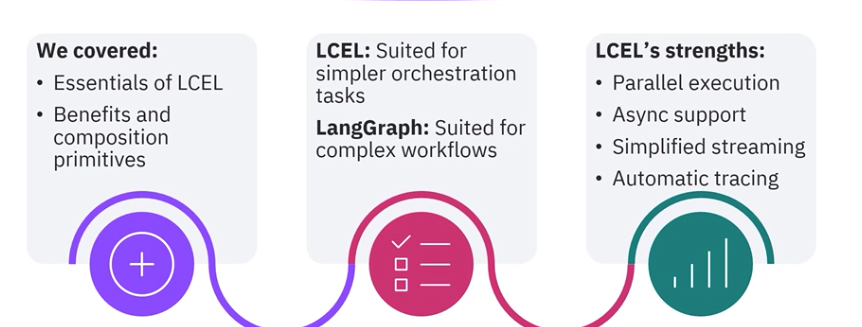


## Manual Tool calling

### When to call tools manually
- Objectives
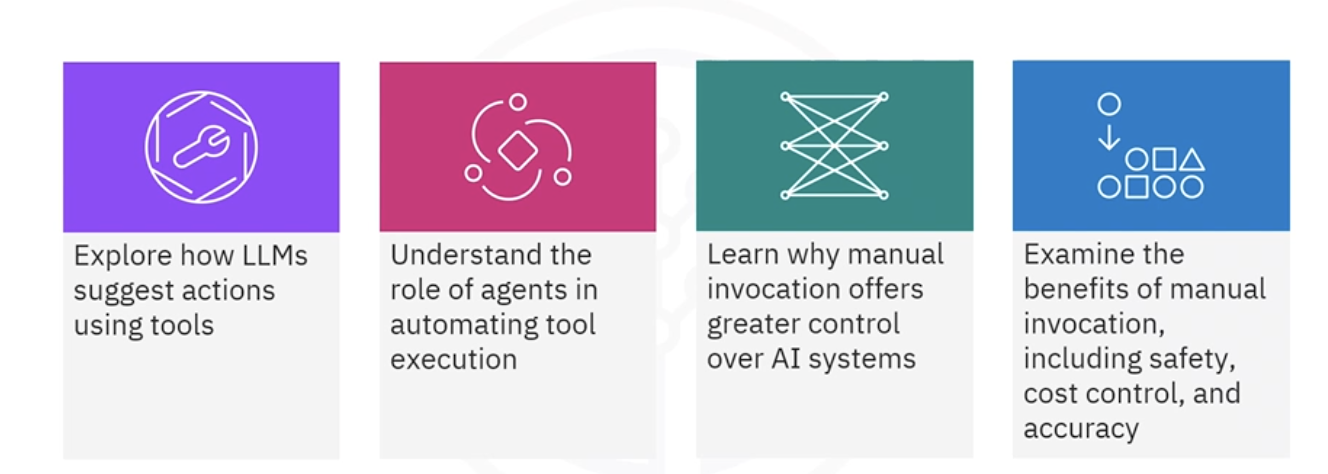

- LLMs suggestion may comes with some risks
    - consider updating a findancail database
        - maz lead to inaccurate reporting
        - Financial losses
        - Regulatory issues

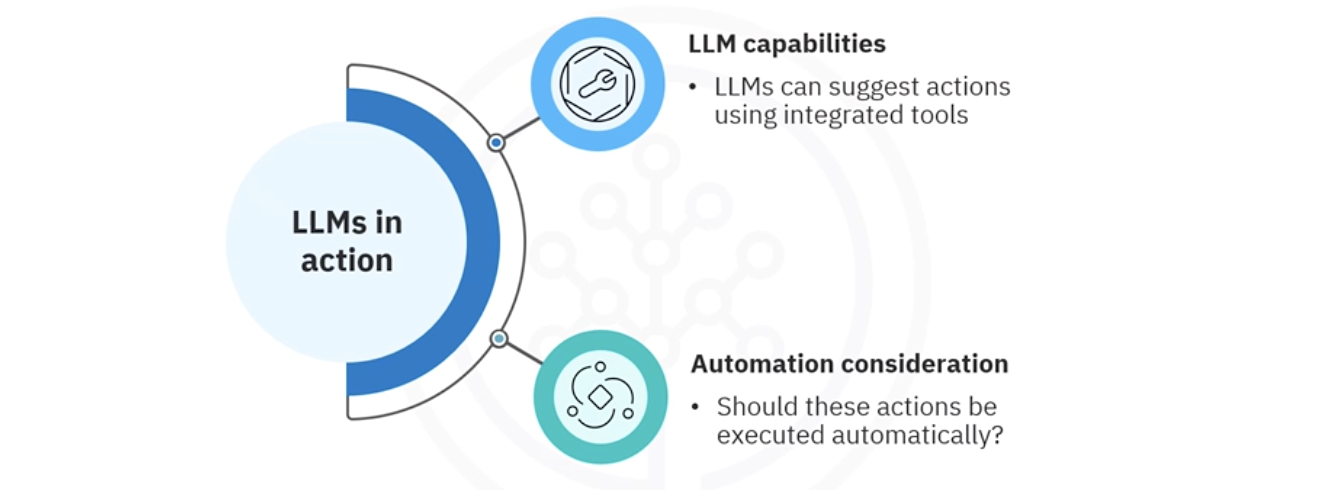
- Manual invocation will lead to
    - greater control
    - safety
    - securtity
    - less problems
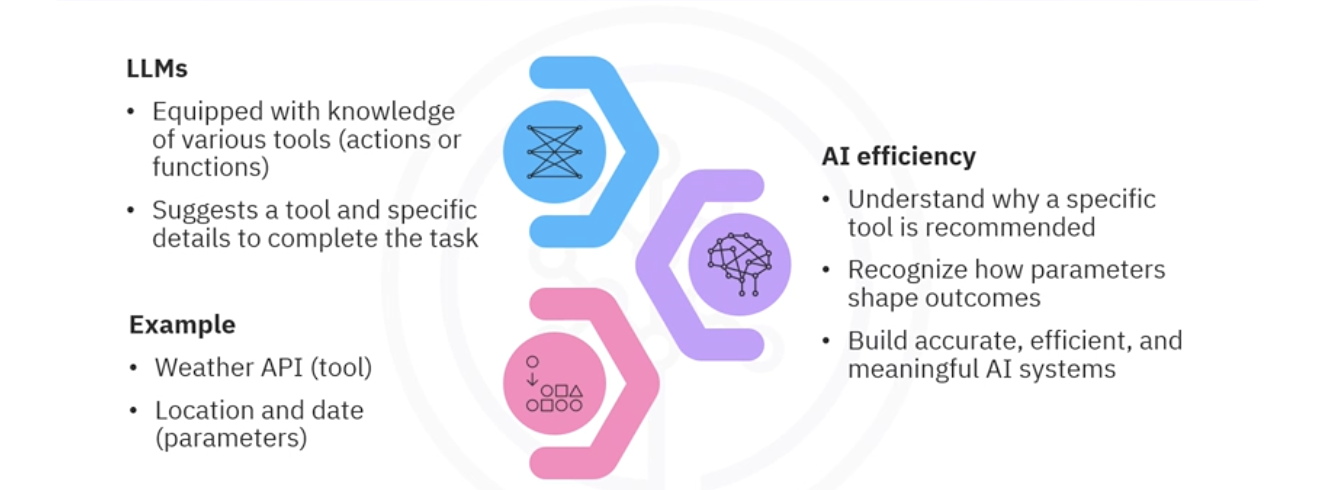

- Manual tool invocation
    - LLMs suggest tool, however human invocate the tool
    - Resons
        - Safety: prevent un intented actions
        - Cost control: Aoid unnecessary API call that might incur charges
        - Accuracy: Ensure that tools are used corretly with right parameters

### Structured output for Tool calling
- defining a schema defenition to LLMs output so that the LLM outputs structed information

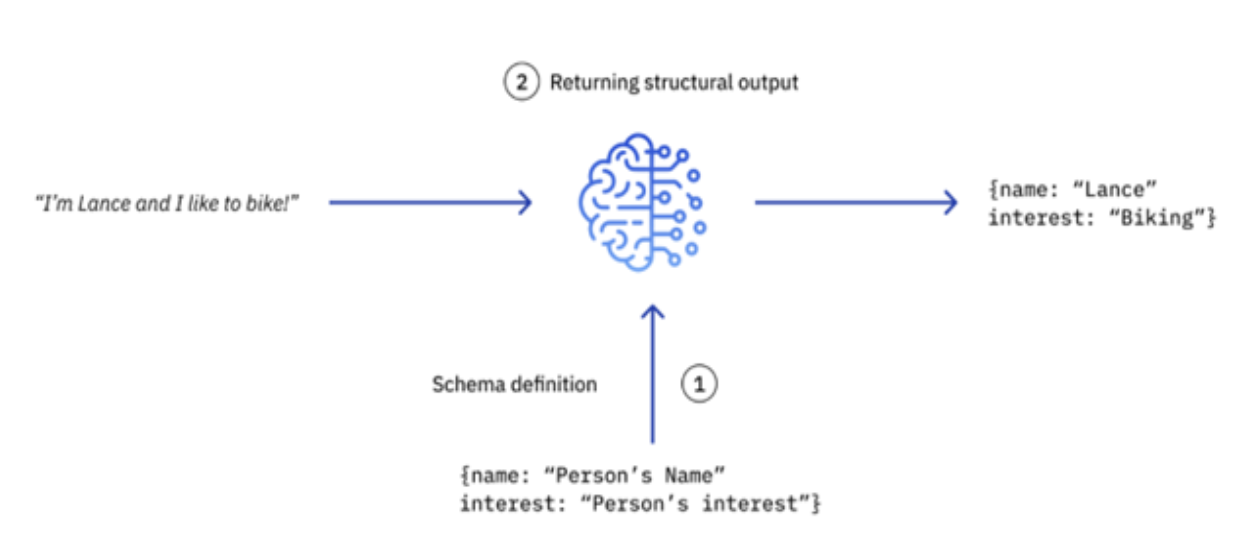

- Schema defenition in LangChain
    - JSON like structure
        - Simplest format
        - represet as a dictionary or list
    - Pydantic models
        - have many advantages like
            - type validaton
            - clear field description
            - Built-in documentation
            - Integration with LangChain tooling
#### Returning structured output
- 2 approach model to return a structured output
    - Tool calling
        - binding a schema to a model as tool
        - when invoked model calls tool and ensures it response conforms to the tool's schema 
        - proess
            - create a model
            - Binding ResponseFormatter schema as a tool to the model
            - Invoke model with users querz
            - Extract the tool call argument as a dictonary
            - Optially, parsing the dictionarz into pydantic object
    - JSON mode
        - some models support JSON mode
        - this enforece tme3 model to produce JSON output
        - process
            - use the `with_structued_output` method with the `json_mode` parameter
        - Return output as a Python dictonary

#### Structed output method: `with_structured_output()`

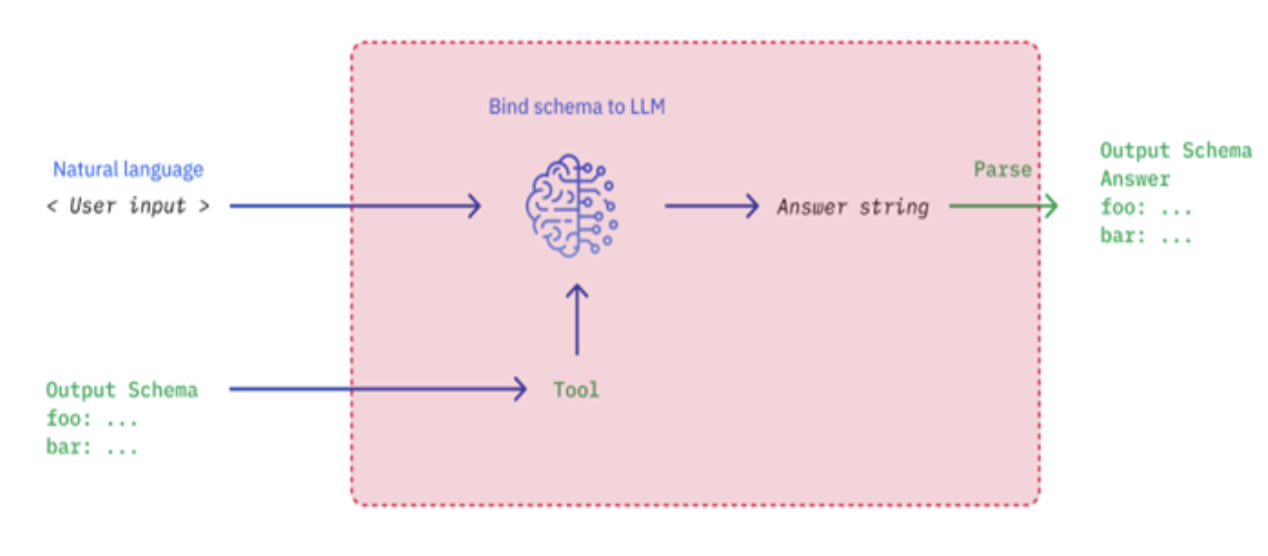

- LangChain provides a method to output structed output

- Process
    - the Output schema is provides as a tool to the LLM
    - User input processed by LLM with this schema in mind
    - the LLM generate an answer string
    - the output is parsed into structed schama format

#### use cases for structured outputs
- Database storage: Format responses for direct storage in databases
- API integration: Structure outputs to match API requirements
- UI components: Format data for display in specific UI elements
- Multi-step workflows: Break down complex tasks into structured steps
- Data extraction: Extract specific information from unstructured text

## Parsing and Validating Tool Calls
### Building LLM Agents with Tools
- Objective
    - Initialize chat model for tool interaction
    - Define and bind custom tools to the LLMs
    - Add more tools for expanded funtionality
    - Use mapping dictionaries for dynamic function calls

- initalize the chat model for tool inteacrtion
- Note: the inti_chat_model, bind_tools() is the modern way of initializing agents in LangChain
- `initialize_agent` is depricated
```python
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    llm = init_chat_model("gtp-4o-mini, mdoel_provider=openai)
)
```

- define a custom tool
```python
@tool
def add (a: int, b:int) -> int:
    """
    Add 2 integers 'a' and 'b'
    """
    return a + b

@tool
def subtract(a:int, b:int) -> int:
    """
    Subtract b from a
    """
    return b-a

@tool
def multiply(a:int, b:int) -> int:
    """
    Multiplz a and b
    """
    return a * b
```

- Add one or more tools to the LLM
```python
tools = [add]
llm_with_tools = llm.bind_tools(tools)
```

- call function dynamically
```python
tool_map = {
    "add": add,
    "susbtract": subtract,
    "multiply": multiply
}

input_ = {"a":1, "b":2}
tool_map[add].invoke(input_)
```

- Bind tools to the LLMs
```python
tools = [add, subtract, multiply]
llm_with_tools = llm.bind_tools(tools)
```

### Build Interacttive LLM Agents
- Objectives
    - Extract tool names and arguments for precise function call
    - Build agent class that manages the entire tool calling process

#### Crafting query
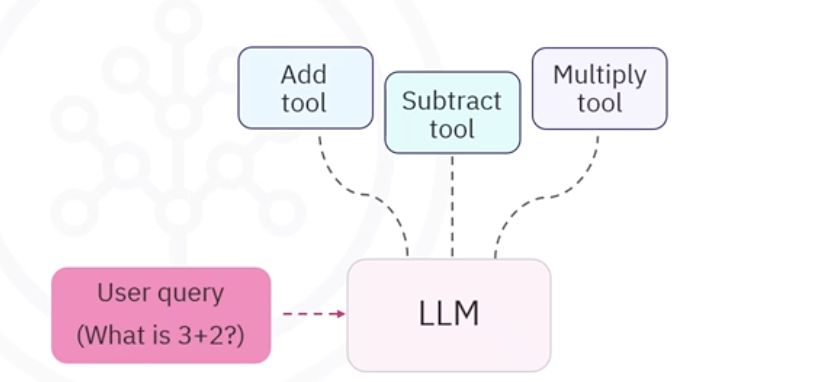

```python
from langchain_core.messages import HumanMessage
chat_history = [HumanMessage(content=query)]
```

- the chat_hsitory will hold all the messages during the converation
    - user inputs
    - tool responses
    - model outputs

#### Invoke the model
    - `response_1 = llm_with_tools.invoke(chat_history)`
    - run the tool-enabled model
    - pass the complete chat history
        - the model check the availabel tools 
        - find the correct tool to process the request
        - and extract the parameters from the query
    - model output
    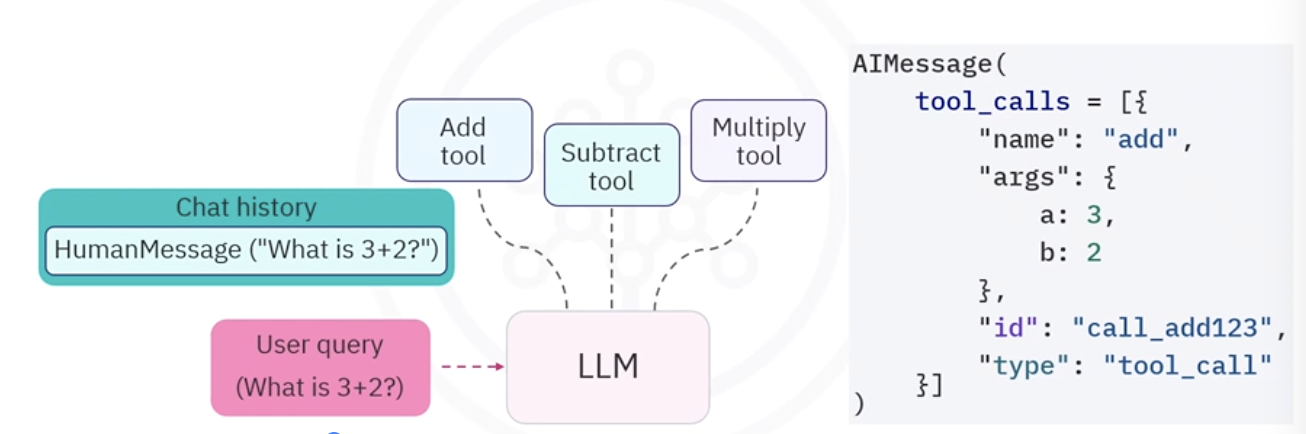

    - insted of plain text, model outputs a structured output   
        - AIMessage
        - id: a unique number that can be referenced to the LLM further communication
            - may be passing the result back to LLM
        - type: tool_call
        - name: is the fuction name
        - arguments: is the arguments values

- We can create an agent class that extract the tool and arguments from the chat_history, execute the tool call and pass the result back to the LLM

- Note: More details on Lab
- Build Interactive LLM Agents with Tools
